# KNN - Cryptocurrency Price Direction Prediction

**Algorithm:** K-Nearest Neighbors (KNN)  
**Dataset:** Top 50 Cryptocurrencies (2014–2026)  
**Task:** Predict whether the next day's closing price will go UP or DOWN

In [1]:
# Google Colab setup - mount Drive if in Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/AI PROJECT DATASET/
    print('Running in Colab - Drive mounted')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

In [3]:
df = pd.read_csv('crypto50_combined.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (115072, 8)


,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,BTC,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,BTC,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,BTC,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,BTC,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,BTC,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115072 entries, 0 to 115071
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Symbol     115072 non-null  str    
 1   Date       115072 non-null  str    
 2   Open       115072 non-null  float64
 3   High       115072 non-null  float64
 4   Low        115072 non-null  float64
 5   Close      115072 non-null  float64
 6   Adj Close  115072 non-null  float64
 7   Volume     115072 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 8.6 MB


In [5]:
# Use Bitcoin (BTC) for simplicity
btc = df[df['Symbol'] == 'BTC'].copy()
btc['Date'] = pd.to_datetime(btc['Date'])
btc = btc.sort_values('Date').reset_index(drop=True)
print(f'BTC rows: {len(btc)}')
btc.head()

BTC rows: 4171


,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,BTC,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,BTC,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,BTC,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,BTC,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,BTC,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


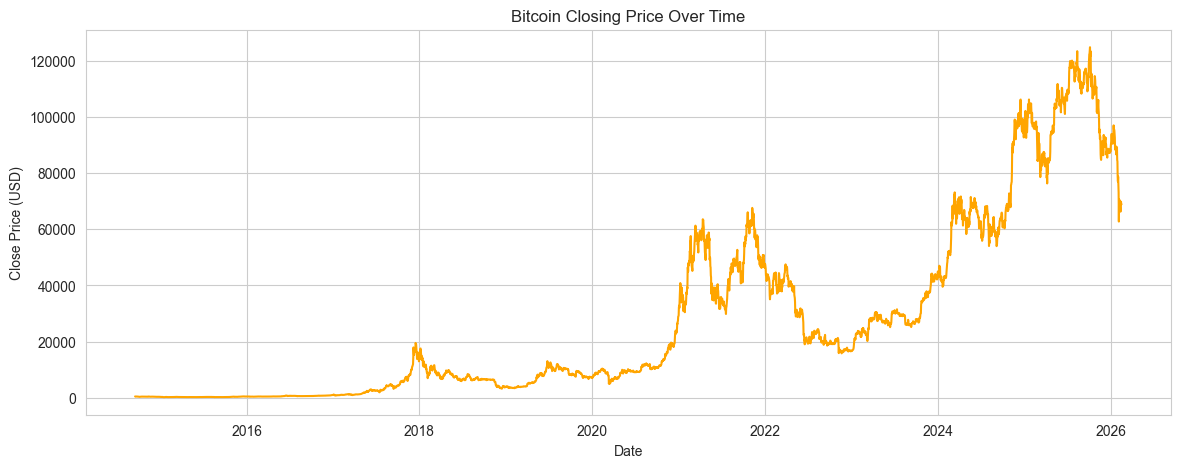

In [6]:
# Plot BTC closing price over time
plt.figure(figsize=(14,5))
plt.plot(btc['Date'], btc['Close'], color='orange')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.show()

### Feature Engineering
- Price returns (daily % change)
- High-Low range
- Moving averages (5-day, 10-day)
- RSI (Relative Strength Index, 14-day)
- Volatility (5-day rolling std of returns)
- Volume change (%)
- Target: 1 if next-day close > today's close, else 0

In [7]:
btc['Return'] = btc['Close'].pct_change()
btc['HL_Range'] = (btc['High'] - btc['Low']) / btc['Close']
btc['MA_5'] = btc['Close'].rolling(5).mean()
btc['MA_10'] = btc['Close'].rolling(10).mean()
btc['Volatility'] = btc['Return'].rolling(5).std()
btc['Volume_Change'] = btc['Volume'].pct_change()
# RSI (Relative Strength Index)
delta = btc['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
btc['RSI'] = 100 - (100 / (1 + gain / loss))

# Target: next-day direction
btc['Target'] = (btc['Close'].shift(-1) > btc['Close']).astype(int)

btc = btc.dropna().reset_index(drop=True)
print(f'Rows after feature engineering: {len(btc)}')
btc.head()

Rows after feature engineering: 4157

,Symbol,Date,Open,High,Low,Close,Adj Close,Volume,Return,HL_Range,MA_5,MA_10,Volatility,Volume_Change,RSI,Target
0,BTC,2014-10-01,387.427002,391.378998,380.779999,383.614990,383.614990,26229400,-0.008603,0.027629,384.545398,399.987396,0.030782,-0.244268,31.461697,0
1,BTC,2014-10-02,383.988007,385.497009,372.946014,375.071991,375.071991,21777700,-0.022270,0.033463,379.655798,397.279395,0.031277,-0.169722,35.852649,0
2,BTC,2014-10-03,375.181000,377.695007,357.859009,359.511993,359.511993,30901200,-0.041485,0.055175,376.121997,389.651495,0.026536,0.418938,39.000831,0
3,BTC,2014-10-04,359.891998,364.487000,325.885986,328.865997,328.865997,47236500,-0.085243,0.117376,366.801794,380.217596,0.042615,0.528630,27.381697,0
4,BTC,2014-10-05,328.915985,341.800995,289.295990,320.510010,320.510010,83308096,-0.025408,0.163817,353.514996,371.111197,0.029599,0.763638,27.651597,1


In [8]:
# Check target balance
btc['Target'].value_counts(normalize=True)

Target
1    0.52586
0    0.47414
Name: proportion, dtype: float64

In [9]:
# Feature selection (engineered features only, no raw prices)
features = ['Return', 'HL_Range', 'MA_5', 'MA_10', 'Volatility', 'Volume_Change', 'RSI']
X = btc[features]
y = btc['Target']

# Train-test split (temporal - use earlier data for training)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)}, Test: {len(X_test)}')


Train: 3325, Test: 832


In [10]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

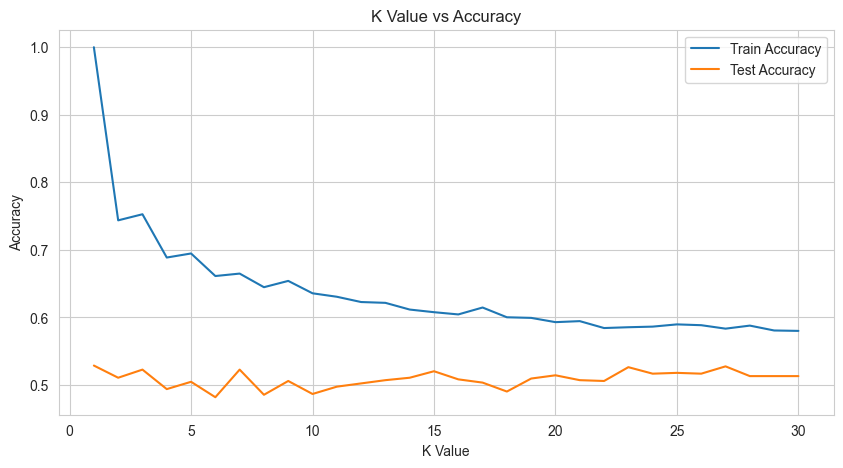

In [11]:
# Find optimal K using Elbow method
train_acc = []
test_acc = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10,5))
plt.plot(k_range, train_acc, label='Train Accuracy')
plt.plot(k_range, test_acc, label='Test Accuracy')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy')
plt.legend()
plt.show()

In [12]:
# Train final model with best K
best_k = k_range[np.argmax(test_acc)]
print(f'Best K: {best_k} (Test Accuracy: {max(test_acc):.4f})')

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)


Best K: 1 (Test Accuracy: 0.5288)


In [13]:
# Evaluation
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

Accuracy: 0.5288

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.61      0.56       408
           1       0.55      0.45      0.49       424

    accuracy                           0.53       832
   macro avg       0.53      0.53      0.53       832
weighted avg       0.53      0.53      0.53       832



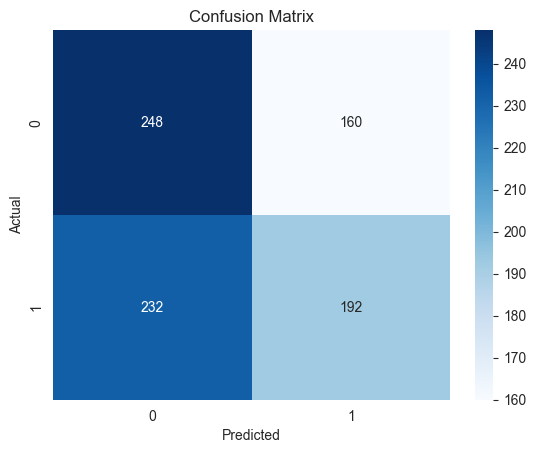

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Conclusion
KNN successfully predicts Bitcoin's next-day price direction using historical patterns. The model finds similar past market conditions and votes on the most likely movement.